In [1]:
import os
import sys
CODE_PATH = "../../OneDrive - J. Craig Venter Institute/Documents/GitHub/frmatch"
sys.path.insert(0, os.path.abspath(CODE_PATH))
import FRmatch
CODE_PATH = "../../OneDrive - J. Craig Venter Institute/Documents/GitHub/nsforest"
sys.path.insert(0, os.path.abspath(CODE_PATH))
from nsforest import ns, nsforesting, utils, NSFOREST_VERSION
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import pickle
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)

This tutorial is for visualizing the FRmatch results. See tutorial_cluster2cluster.py for running FRmatch.

Pseudocode for running FRmatch

1. **Defining frmatch feature space.** The set of genes is the union of HLCA and CellRef binary_genes. 

2. **Preparing frmatch anndata object.** Subsets anndata to specified feature space. Creates anndata.uns structure: dendrogram, markers, markers_per_cluster. Saves as new file if specified.

3. **Binning anndata objects.** If the query or reference dataset has more than 100k cells, it is recommended to run frmatch on a subset. 

4. **Normalization.** Normalizing query and reference anndata. norm_by = "mean". Ensures the anndata objects can be compared with different count distributions. 

5. **FRmatch.FRmatch_cluster2cluster.** Runs the main FRmatch algorithm. For each query-reference cluster pair, subsample the cells and generate a minimum spanning tree (MST). Calculate the p-values. Recommended to run twice: HLCA to CellRef and CellRef to HLCA. 

6. **Visualizing results.** Input is the p-value matrix. Specified p-value adjustment is applied and only p-values greater than the threshold are included. Heatmap to visualize the two-way or one-way cluster2cluster matching. 

In [2]:
# Iterating FRmatch results and getting the p_values
results_HLCAtoCellRef_3 = {"settings": {}, "p_values": pd.DataFrame(), "stat": pd.DataFrame()}
for bin_ in range(6): 
    with open(f'tutorial_hlca_cellref/results_HLCAtoCellRef_cluster2cluster_bin{bin_}.pkl', 'rb') as f: 
        results_HLCAtoCellRef_6 = pickle.load(f)
        results_HLCAtoCellRef_3["p_values"] = pd.merge(results_HLCAtoCellRef_3["p_values"], results_HLCAtoCellRef_6["p_values"], left_index=True, right_index=True, how='outer')
print(results_HLCAtoCellRef_3.keys())

results_CellReftoHLCA_3 = {"settings": {}, "p_values": pd.DataFrame(), "stat": pd.DataFrame()}
for bin_ in range(6): 
    with open(f'tutorial_hlca_cellref/results_CellReftoHLCA_cluster2cluster_bin{bin_}.pkl', 'rb') as f: 
        results_CellReftoHLCA_6 = pickle.load(f)
        results_CellReftoHLCA_3["p_values"] = pd.merge(results_CellReftoHLCA_3["p_values"], results_CellReftoHLCA_6["p_values"], left_index=True, right_index=True, how='outer')
print(results_CellReftoHLCA_3.keys())

dict_keys(['settings', 'p_values', 'stat'])
dict_keys(['settings', 'p_values', 'stat'])


In [3]:
# Defining manual cluster order (not necessary) for visualization
order_hlca = ['Alveolar Mph MT-positive', 'Alveolar Mph CCL3+', 'Alveolar macrophages', 'Alveolar Mph proliferating', 
              'DC2', 'DC1', 'Migratory DCs', 'Classical monocytes', 'Non-classical monocytes', 'Monocyte-derived Mph', 
              'Interstitial Mph perivascular', 'Hematopoietic stem cells', 'Mast cells', 'T cells proliferating', 
              'NK cells', 'CD4 T cells', 'CD8 T cells', 'Plasma cells', 'B cells', 'Plasmacytoid DCs', 
              'Lymphatic EC mature', 'Lymphatic EC proliferating', 'Mesothelium', 'Adventitial fibroblasts', 
              'Subpleural fibroblasts', 'Peribronchial fibroblasts', 'Alveolar fibroblasts', 'Myofibroblasts', 
              'SM activated stress response', 'Pericytes', 'Smooth muscle', 'Smooth muscle FAM83D+', 'EC venous systemic', 
              'EC arterial', 'EC venous pulmonary', 'Lymphatic EC differentiating', 'EC aerocyte capillary', 
              'EC general capillary', 'Suprabasal', 'Hillock-like', 'Basal resting', 'Tuft', 'SMG mucous', 
              'SMG serous (nasal)', 'SMG serous (bronchial)', 'AT2', 'AT2 proliferating', 'AT0', 'pre-TB secretory', 
              'Club (nasal)', 'Goblet (nasal)', 'Goblet (bronchial)', 'Goblet (subsegmental)', 'Club (non-nasal)', 
              'SMG duct', 'AT1', 'Ionocyte', 'Neuroendocrine', 'Deuterosomal', 'Multiciliated (nasal)', 
              'Multiciliated (non-nasal)']
order_cellref = ['Alveolar macrophage', 'Classical DC subset 2', 'Classical DC subset 1', 'Mature DC subset', 
                 'Inflammatory monocyte', 'Patrolling monocyte', 'Interstitial macrophage', 
                 'Mast/Basophil', 'Innate lymphoid cell', 'Natural killer cell', 'CD4+ T cell', 'T regulatory cell', 
                 'CD8+ T cell', 'Plasma cell', 'B cell', 'Plasmacytoid DC', 'Lymphatic endothelial cell', 'Mesothelial cell', 
                 'Alveolar fibroblast 2', 'Alveolar fibroblast 1', 'Secondary crest myofibroblast', 'Pericyte', 
                 'Vascular smooth muscle cell', 'Airway smooth muscle cell', 'Systemic venous endothelial cell', 
                 'Arterial endothelial cell', 'Venous endothelial cell', 'Capillary 2 cell', 'Capillary 1 cell', 
                 'Basal cell', 'Suprabasal cell', 'Tuft cell', 'Mucous cell', 'Serous cell', 
                 'Alveolar type 2 cell', 'Respiratory airway secretory cell', 'Secretory cell', 'Goblet cell', 
                 'SMG Basal/Duct cell', 'Alveolar type 1 cell', 'Ionocyte', 'Pulmonary neuroendocrine cell', 
                 'Deuterosomal cell', 'Ciliated cell', 'Myoepithelial cell', 'Neutrophil', 'Megakaryocyte/Platelet', 
                 'Chondrocyte']

In [ ]:
results_HLCAtoCellRef = results_HLCAtoCellRef_3["p_values"].copy()
results_HLCAtoCellRef.columns.name = None
results_HLCAtoCellRef.index.name = None
results_CellReftoHLCA = results_CellReftoHLCA_3["p_values"].copy()
results_CellReftoHLCA.columns.name = None
results_CellReftoHLCA.index.name = None

In [4]:
# Sorting dataframe according to order_cellref and order_hlca
results_HLCAtoCellRef = results_HLCAtoCellRef.iloc[pd.Categorical(results_HLCAtoCellRef.index, order_cellref).argsort()]
sorted_col_positions = pd.Categorical(results_HLCAtoCellRef.columns, categories = order_hlca).argsort()
sorted_columns = results_HLCAtoCellRef.columns[sorted_col_positions]
results_HLCAtoCellRef = results_HLCAtoCellRef.loc[:, sorted_columns]
results_HLCAtoCellRef

results_CellReftoHLCA = results_CellReftoHLCA.iloc[pd.Categorical(results_CellReftoHLCA.index, order_hlca).argsort()]
sorted_col_positions = pd.Categorical(results_CellReftoHLCA.columns, categories = order_cellref).argsort()
sorted_columns = results_CellReftoHLCA.columns[sorted_col_positions]
results_CellReftoHLCA = results_CellReftoHLCA.loc[:, sorted_columns]
results_CellReftoHLCA

,Alveolar macrophage,Classical DC subset 2,Classical DC subset 1,Mature DC subset,Inflammatory monocyte,Patrolling monocyte,Interstitial macrophage,Mast/Basophil,Innate lymphoid cell,Natural killer cell,CD4+ T cell,T regulatory cell,CD8+ T cell,Plasma cell,B cell,Plasmacytoid DC,Lymphatic endothelial cell,Mesothelial cell,Alveolar fibroblast 2,Alveolar fibroblast 1,Secondary crest myofibroblast,Pericyte,Vascular smooth muscle cell,Airway smooth muscle cell,Systemic venous endothelial cell,Arterial endothelial cell,Venous endothelial cell,Capillary 2 cell,Capillary 1 cell,Basal cell,Suprabasal cell,Tuft cell,Mucous cell,Serous cell,Alveolar type 2 cell,Respiratory airway secretory cell,Secretory cell,Goblet cell,SMG Basal/Duct cell,Alveolar type 1 cell,Ionocyte,Pulmonary neuroendocrine cell,Deuterosomal cell,Ciliated cell,Myoepithelial cell,Neutrophil,Megakaryocyte/Platelet
Alveolar Mph MT-positive,0.000009,0.000009,0.000010,0.000009,0.000010,0.000010,0.000009,0.000009,0.000009,0.000009,0.000010,0.000009,0.000009,0.000011,0.000010,0.000009,0.000009,0.000010,0.000009,0.000010,0.000010,0.000009,0.000010,0.000010,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000010,0.000009,0.000010,0.000011,0.000009,0.000010,0.000010,0.000011,0.000011,0.000010,0.000009,0.000009,0.000010,0.000009,0.000010,0.000010,0.000011
Alveolar Mph CCL3+,0.000051,0.000009,0.000010,0.000009,0.000010,0.000010,0.000010,0.000009,0.000009,0.000009,0.000010,0.000009,0.000009,0.000011,0.000010,0.000009,0.000009,0.000010,0.000009,0.000010,0.000010,0.000009,0.000009,0.000010,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000010,0.000009,0.000010,0.000011,0.000009,0.000010,0.000010,0.000010,0.000011,0.000010,0.000009,0.000009,0.000010,0.000009,0.000010,0.000010,0.000010
Alveolar macrophages,0.000338,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000010,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000010,0.000009,0.000009,0.000009,0.000010,0.000010,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000010
Alveolar Mph proliferating,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000009,0.000009,0.000011,0.000010,0.000009,0.000009,0.000010,0.000009,0.000010,0.000009,0.000009,0.000009,0.000010,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000010,0.000009,0.000010,0.000010,0.000009,0.000010,0.000009,0.000010,0.000011,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000011
DC2,0.000009,0.008161,0.000010,0.000009,0.000010,0.000010,0.000010,0.000009,0.000009,0.000009,0.000010,0.000009,0.000009,0.000011,0.000010,0.000009,0.000010,0.000010,0.000009,0.000010,0.000010,0.000009,0.000009,0.000010,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000010,0.000009,0.000011,0.000011,0.000009,0.000010,0.000010,0.000010,0.000011,0.000010,0.000009,0.000009,0.000010,0.000009,0.000010,0.000010,0.000011
DC1,0.000009,0.000009,0.001788,0.000009,0.000009,0.000009,0.000010,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000011,0.000010,0.000009,0.000009,0.000010,0.000009,0.000010,0.000010,0.000009,0.000009,0.000010,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000009,0.000010,0.000010,0.000009,0.000010,0.000010,0.000010,0.000010,0.000010,0.000009,0.000009,0.000009,0.000009,0.000010,0.000010,0.000011
Migratory DCs,0.000009,0.000009,0.000010,0.002108,0.000009,0.000010,0.000010,0.000009,0.000009,0.000009,0.000010,0.000009,0.000009,0.000011,0.000010,0.000009,0.000009,0.000010,0.000009,0.000010,0.000009,0.000009,0.000009,0.000010,0.000009,0.000009,0.000009,0.000009,0.000009,0.000010,0.000010,0.000009,0.000010,0.000010,0.000009,0.000010,0.000010,0.000010,0.000011,0.000010,0.000009,0.000009,0.000010,0.000009,0.000009,0.000010,0.000011
Classical monocytes,0.000009,0.000009,0

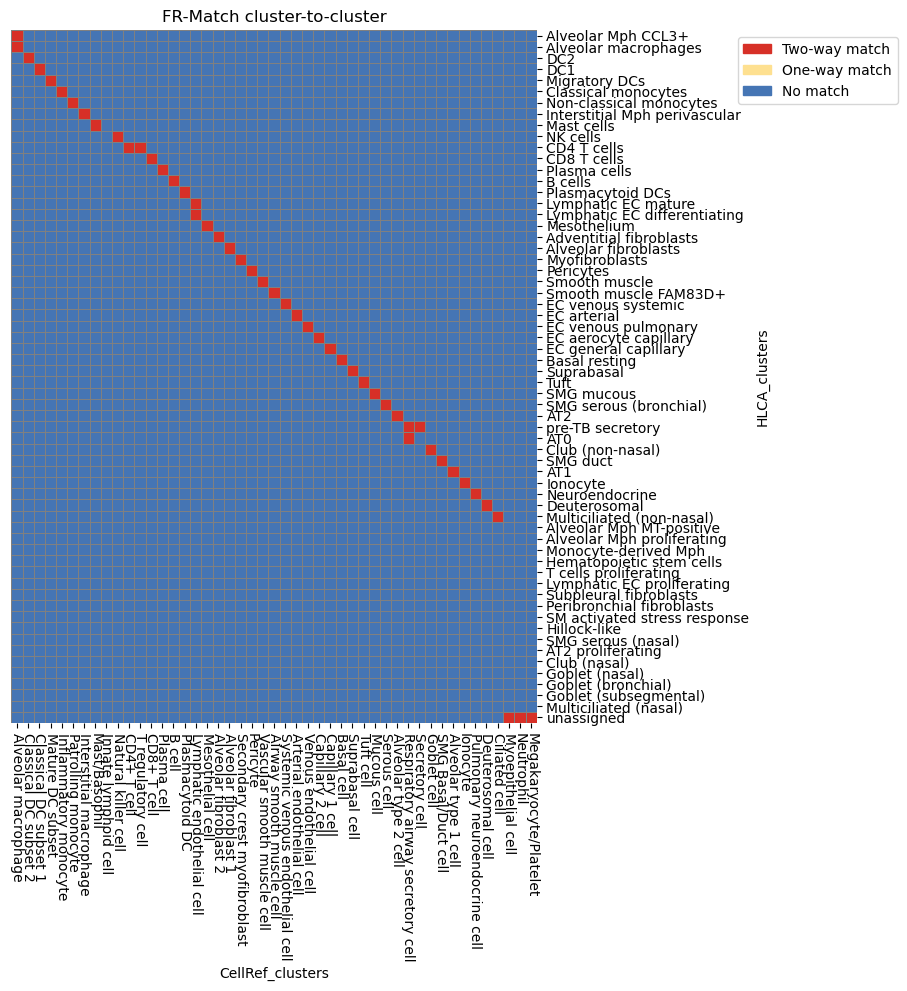

In [5]:
# Plotting 2-way frmatch cluster2cluster results for HLCA->CellRef and CellRef->HLCA
FRmatch.plot_bi_FRmatch(results_CellReftoHLCA, results_HLCAtoCellRef, prefix = ["CellRef_", "HLCA_"], two_way_only = True,
                        p_adj_method = "bonferroni", reorder = True, marker_legend_loc = (1.7, 1), width = 12, height = 9)

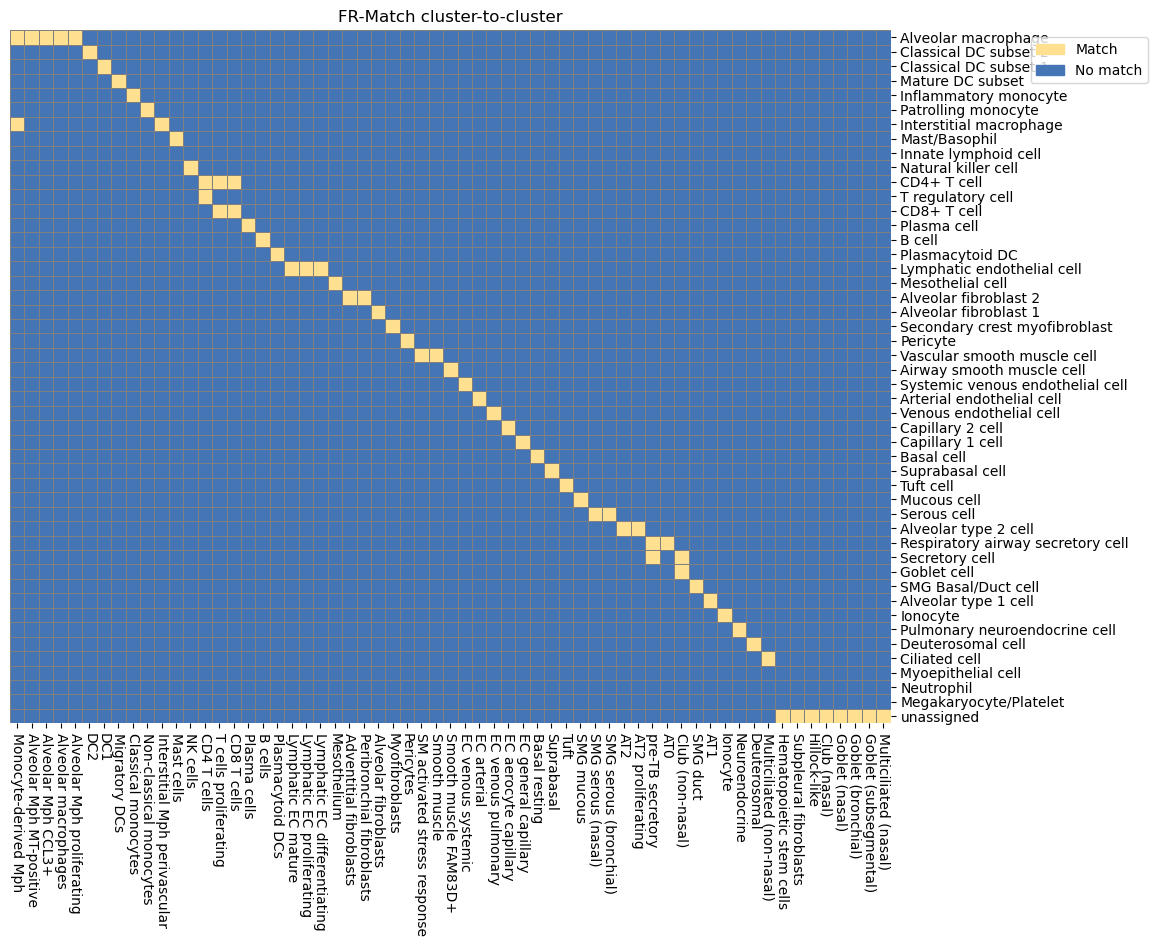

In [6]:
# Plotting 1-way frmatch cluster2cluster results for HLCA->CellRef
FRmatch.plot_FRmatch(results_HLCAtoCellRef, p_adj_method = "bonferroni", marker_legend_loc = (1.3, 1), width = 12, height = 9)

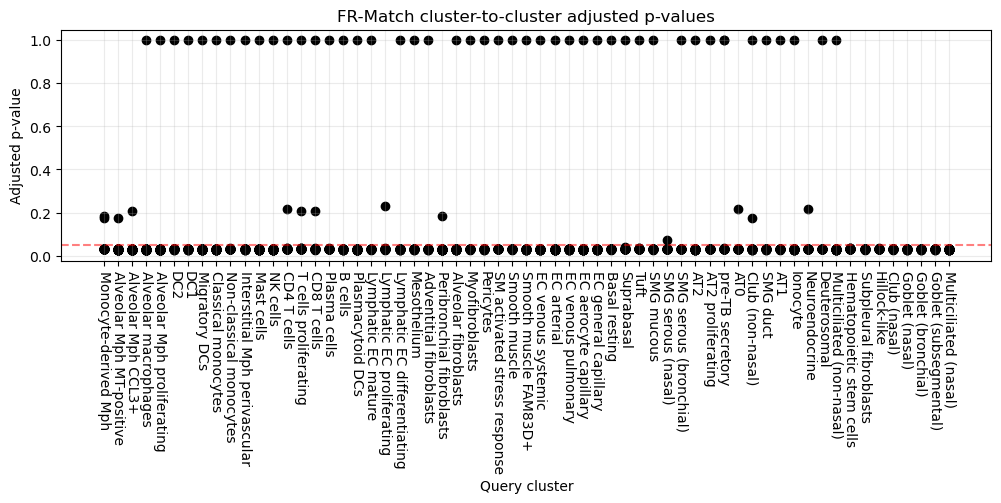

In [7]:
# Plotting adjusted p-values for HLCA->CellRef results
# Values above the threshold (red line) are considered significant
# Each dot represents the query cluster to reference cluster p-value
# Each query-reference combination has been evaluated
FRmatch.plot_FRmatch(results_HLCAtoCellRef, type_ = "padj", p_adj_method = "bonferroni", 
                     marker_legend_loc = (1.3, 1), width = 12, height = 3)

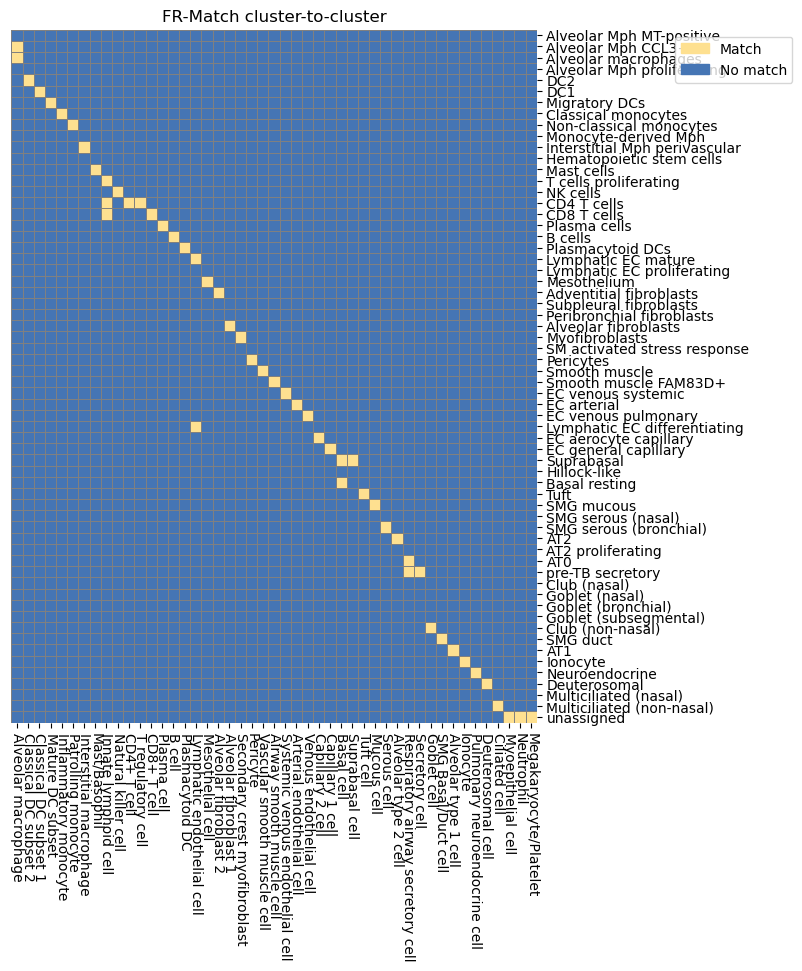

In [8]:
# Plotting 1-way frmatch cluster2cluster results for CellRef->HLCA
FRmatch.plot_FRmatch(results_CellReftoHLCA, p_adj_method = "bonferroni", marker_legend_loc = (1.5, 1), width = 10, height = 9)

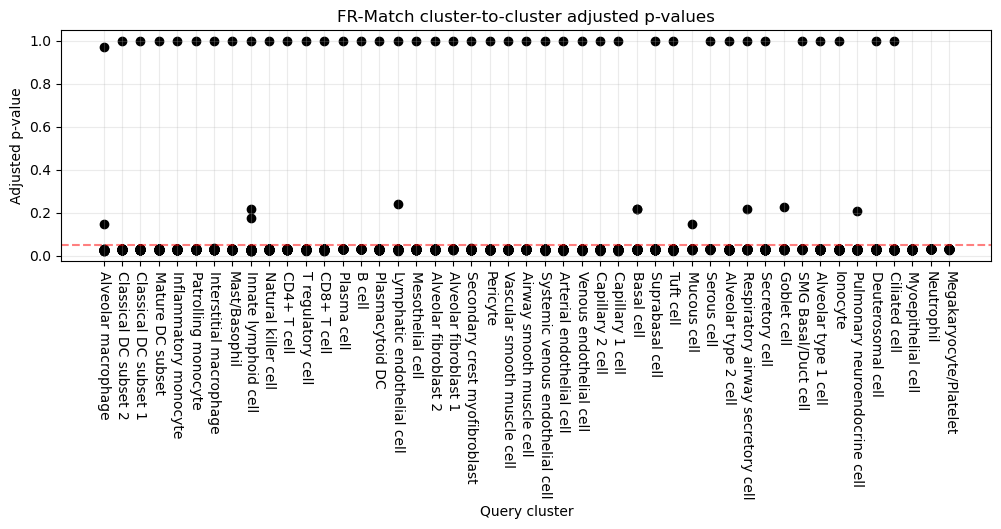

In [9]:
# Plotting adjusted p-values for CellRef->HLCA results
# Values above the threshold (red line) are considered significant
# Each dot represents the query cluster to reference cluster p-value
# Each query-reference combination has been evaluated
FRmatch.plot_FRmatch(results_CellReftoHLCA, type_ = "padj", p_adj_method = "bonferroni", 
                     marker_legend_loc = (1.5, 1), width = 12, height = 3)